## Run a pipeline adding a custom algorithm

This process will run the entire pipeline described in a configuration file and will add a custom algorithm to it

## Import dependencies

In [15]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Instantiate the Pipeline class

When you instantiate the pipeline class, it will install some dependencies described in the configuration file that are necessary for the custom algorithm

In [16]:
pipeline = Pipeline(config_file_path="../config_files/config_custom_algorithm.yml")

This occurs because of the following step that you added in the conf file:

```
steps:
    ...

  - custom:
      name: "min_max_data"
      file_path: "/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py"
      class_name: "MyMethod"
      dependencies:
        - "scikit-learn"
      params:
        feature_range: (0, 1)
```

In this case, you are saying that you need to install scikit-learn to use the custom algorithm

In [17]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_type": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "is_remote": false,
        "output_is_remote": false,
        "output_path": "output",
        "n_jobs": 1,
        "client": null,
        "track_changes": true,
        "rename": "datetime",
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "mode": "percent",
                "test": false,
                "params": {
                    "value": 0.1,
                    "raise_error": false
                }
            }
     

In [18]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [19]:
# See the pipeline steps in json format
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'name': 'raw',
   'step_name': 'open',
   'sample_data': 'benthic_csv',
   'input_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/images'),
   'metadata_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv'),
   'metadata_type': 'CSV_FILE',
   'image_type': 'PNG',
   'append_data_to_metadata': '/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv',
   'is_remote': False,
   'output_is_remote': False,
   'output_path': PosixPath('output'),
   'n_jobs': 1,
   'client': None,
   'track_changes': True,
   'rename': 'datetime',
   'sampling': [{'name': 'sampling',
     'step_name': 'sampling',
     'mode': 'percent',
     'test': False,
     'params': {'value': 0.1, 'raise_error': False}}],
   'convert': [{'name': 'convert',
     'step_name': 'convert',
     'mode': 'bits',
     'test': False,
     'params': {'output_bits': 8, 'raise_error': False

The `min_max_data` is a custom algorithm available in `file_path`: `/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py`

In [20]:
# Run the pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-02-27 11:41:28 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-02-27 11:41:28 | Running step 0: raw - OpenLayer


Processing images:   0%|                                                                         | 0/5 [00:00<?, ?it/s]

☁ paidiverpy ☁  |    WARNING | 2025-02-27 11:41:28 | Unsupported output bits or image already within provided format: 8
☁ paidiverpy ☁  |    WARNING | 2025-02-27 11:41:28 | Unsupported output bits or image already within provided format: 8
☁ paidiverpy ☁  |    WARNING | 2025-02-27 11:41:28 | Unsupported output bits or image already within provided format: 8
☁ paidiverpy ☁  |    WARNING | 2025-02-27 11:41:28 | Unsupported output bits or image already within provided format: 8
☁ paidiverpy ☁  |    WARNING | 2025-02-27 11:41:28 | Unsupported output bits or image already within provided format: 8


Processing images: 100%|███████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 3852.23it/s]


☁ paidiverpy ☁  |       INFO | 2025-02-27 11:41:28 | Step 0 completed
☁ paidiverpy ☁  |       INFO | 2025-02-27 11:41:28 | Running step 1: colour_correction - ColourLayer


Processing images: 100%|██████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 30305.66it/s]

☁ paidiverpy ☁  |       INFO | 2025-02-27 11:41:29 | Step 1 completed


☁ paidiverpy ☁  |       INFO | 2025-02-27 11:41:29 | Running step 2: min_max_data - CustomLayer


Processing images: 100%|███████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 2314.99it/s]

☁ paidiverpy ☁  |       INFO | 2025-02-27 11:41:29 | Step 2 completed


Step: raw
Image: dask.array<array, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Step: colour_correction
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Step: min_max_data
Image: dask.array<array, shape=(128, 128), dtype=float64, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=float64, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=float64, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=float64, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=float64, chunksize=(128, 128), chunktype=numpy.ndarray>
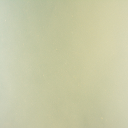
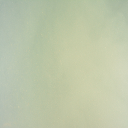
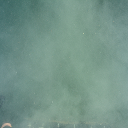
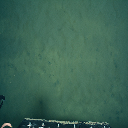
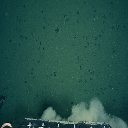
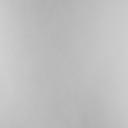
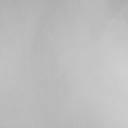
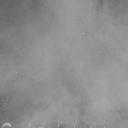
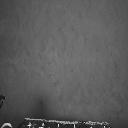
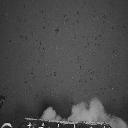
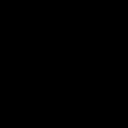
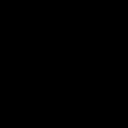
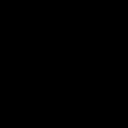
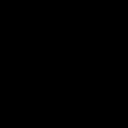
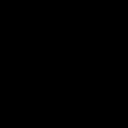

In [14]:
# See the images output
pipeline.images